<a id="top"></a>
# Estimating Galaxy Cluster Masses with Convolutional Neural Networks

***

## Imports
This notebook uses the following:
- *numpy* to handle array functions
- *astropy.io fits* for accessing FITS files
- *matplotlib.pyplot* for plotting data
- *keras* for building the CNN

In [18]:
%matplotlib widget
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import keras
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D
from keras.layers import GlobalAveragePooling2D
from keras.callbacks import Callback

filename = 'cluster_TNG_data.fits'
hdul = fits.open(filename)
images = hdul[1].data
image_size = images.shape[1]
print('Approach 3 training device: CPU:0')

Approach 3 training device: CPU:0


## Add cluster aware cross-validation

The following cells convert the FITS metadata to a DataFrame, check cluster completeness, and run cluster-aware cross-validation.

In [2]:
data = {}

table = hdul[2].data

for name in table.names:
    arr = np.array(table[name])

    if arr.dtype.byteorder not in ('=', '|'):
        arr = arr.astype(arr.dtype.newbyteorder('='))

    data[name] = arr

df = pd.DataFrame(data)

### 3. Check cluster completeness

Each complete cluster should contain exactly the three lines of sight: `x`, `y`, and `z`. Incomplete clusters are excluded from cross-validation.

In [3]:
# Verify that every cluster has exactly the three expected lines of sight.
los_by_cluster = df.groupby('cluster_id')['view_los'].agg(lambda values: set(values))
expected_los = set(df['view_los'].dropna().unique())
complete_clusters = los_by_cluster[los_by_cluster == expected_los].index.to_numpy()
incomplete_clusters = los_by_cluster[los_by_cluster != expected_los]

print(f'Expected lines of sight: {sorted(expected_los)}')
print(f'Complete clusters: {len(complete_clusters)} out of {len(los_by_cluster)}')
print('Incomplete or duplicated clusters:')
print(incomplete_clusters)

assert all(len(df[df['cluster_id'] == cid]) == len(expected_los) for cid in complete_clusters), \
    'At least one cluster has duplicate rows for a line of sight.'

Expected lines of sight: ['x', 'y', 'z']
Complete clusters: 328 out of 329
Incomplete or duplicated clusters:
cluster_id
0    {y, z}
Name: view_los, dtype: object


In [4]:
images = hdul[1].data

### 6. Cluster-level mass-balanced 10-fold cross-validation

The CV loop splits complete `cluster_id` groups, so all three lines of sight remain in the same fold. Clusters are sorted by true mass and assigned round-robin to folds, giving each fold a similar mass distribution without allowing augmented copies of a validation cluster into training. Each model trains for up to 400 epochs and stops early when all three requested convergence criteria are satisfied; otherwise the model at epoch 400 is used.

In [5]:
n_folds = 10
max_epochs = 200
batch_size = 64

# `clusters` contains one entry per cluster, not one entry per image.
# Therefore fold assignment happens before augmentation and keeps each cluster intact.
clusters = np.sort(complete_clusters)
assert len(clusters) >= n_folds

cluster_indices = {
    cid: df.index[df['cluster_id'] == cid].to_numpy()
    for cid in clusters
}
cluster_masses = {
    cid: df.loc[df['cluster_id'] == cid, 'log_M500'].iloc[0]
    for cid in clusters
}
norm_cv = np.nanmin(list(cluster_masses.values()))
cluster_masses = {cid: mass - norm_cv for cid, mass in cluster_masses.items()}


def make_mass_balanced_folds(cluster_ids, masses, n_splits, seed=42):
    """Assign nearby mass ranks to different folds while preserving clusters."""
    rng = np.random.default_rng(seed)
    order = np.argsort([masses[cid] for cid in cluster_ids], kind='stable')
    sorted_clusters = np.asarray(cluster_ids)[order]
    folds = [[] for _ in range(n_splits)]
    for rank, cluster_id in enumerate(sorted_clusters):
        folds[rank % n_splits].append(cluster_id)
    rng.shuffle(folds)
    return [np.asarray(fold) for fold in folds]

mass_balanced_folds = make_mass_balanced_folds(
    clusters, cluster_masses, n_folds
)
print('Mass-balanced fold summaries:')
for fold, fold_clusters in enumerate(mass_balanced_folds, start=1):
    fold_values = np.asarray([cluster_masses[cid] for cid in fold_clusters])
    print(
        f'Fold {fold}: {len(fold_clusters)} clusters, '
        f'mass range [{fold_values.min():.3f}, {fold_values.max():.3f}], '
        f'median={np.median(fold_values):.3f}'
    )

Mass-balanced fold summaries:
Fold 1: 33 clusters, mass range [0.153, 1.226], median=0.416
Fold 2: 33 clusters, mass range [0.156, 1.273], median=0.418
Fold 3: 33 clusters, mass range [0.000, 1.021], median=0.405
Fold 4: 33 clusters, mass range [0.163, 1.410], median=0.418
Fold 5: 33 clusters, mass range [0.095, 1.100], median=0.410
Fold 6: 33 clusters, mass range [0.066, 1.082], median=0.409
Fold 7: 33 clusters, mass range [0.145, 1.204], median=0.411
Fold 8: 32 clusters, mass range [0.175, 1.019], median=0.414
Fold 9: 33 clusters, mass range [0.064, 1.046], median=0.408
Fold 10: 32 clusters, mass range [0.173, 1.016], median=0.412


In [6]:
def build_model(with_rotation=False, input_shape=(*images.shape[1:], 1)):
    model_layers = [Input(shape=input_shape)]
    if with_rotation:
        model_layers.extend([
            keras.layers.RandomRotation(0.25),
            keras.layers.RandomFlip('horizontal'),
            keras.layers.RandomFlip('vertical')
        ])
    model_layers.extend([
        Conv2D(16, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        GlobalAveragePooling2D(),
        Dropout(0.1),
        Dense(200, activation='relu'),
        Dropout(0.1),
        Dense(100, activation='relu'),
        Dense(20, activation='relu'),
        Dense(1, activation='linear')
    ])
    model = Sequential(model_layers)
    model.compile(loss='mean_squared_error',
                  optimizer=keras.optimizers.Adam(learning_rate=0.0002),
                  run_eagerly=False,
                  jit_compile=False)
    return model

# Aproch 3

## Approach 3: Explicit geometric augmentation followed by 10-fold CV

This approach explicitly applies the geometric symmetries of a square image to each original image. We consider the original image, horizontal and vertical flips, and rotations by 90, 180, and 270 degrees. These operations are not all independent: combining a flip with rotations produces the same eight transformations as the dihedral group of the square.

For a generic image, there are at most eight distinct outputs per original image. Therefore, three lines of sight can produce at most `3 x 8 = 24` unique images per cluster. Exact duplicates are removed below, so symmetric images cannot be counted twice.

The folds are assigned using the original cluster IDs before or alongside augmentation. Every augmented copy inherits its source cluster ID and mass, so all copies of a cluster remain in one fold. The CV model uses `with_rotation=False` because the rotations have already been materialized in the dataset; adding Keras `RandomRotation` would apply another, separate augmentation on top of them.

In [7]:
def geometric_variants(image):
    """Return exact unique D4 variants of one square image."""
    candidates = []
    transform_names = []
    for rotation in range(4):
        rotated = np.rot90(image, rotation)
        for flip_name, candidate in [
            ('none', rotated),
            ('horizontal', np.fliplr(rotated)),
            ('vertical', np.flipud(rotated)),
        ]:
            if not any(np.array_equal(candidate, previous) for previous in candidates):
                candidates.append(candidate.copy())
                transform_names.append(f'rot{rotation * 90}_{flip_name}')
    return candidates, transform_names

# Show the redundancy count for one representative cluster.
example_cluster = clusters[0]
example_indices = cluster_indices[example_cluster]
example_counts = []
for source_index in example_indices:
    variants, names = geometric_variants(images[source_index])
    example_counts.append(len(variants))

print(f'Example cluster {example_cluster}: {len(example_indices)} original images')
print(f'Unique variants per image: {example_counts}')
print(f'Unique augmented images in this cluster: {sum(example_counts)}')
assert all(count <= 8 for count in example_counts)
assert sum(example_counts) <= 24

Example cluster 1: 3 original images
Unique variants per image: [8, 8, 8]
Unique augmented images in this cluster: 24


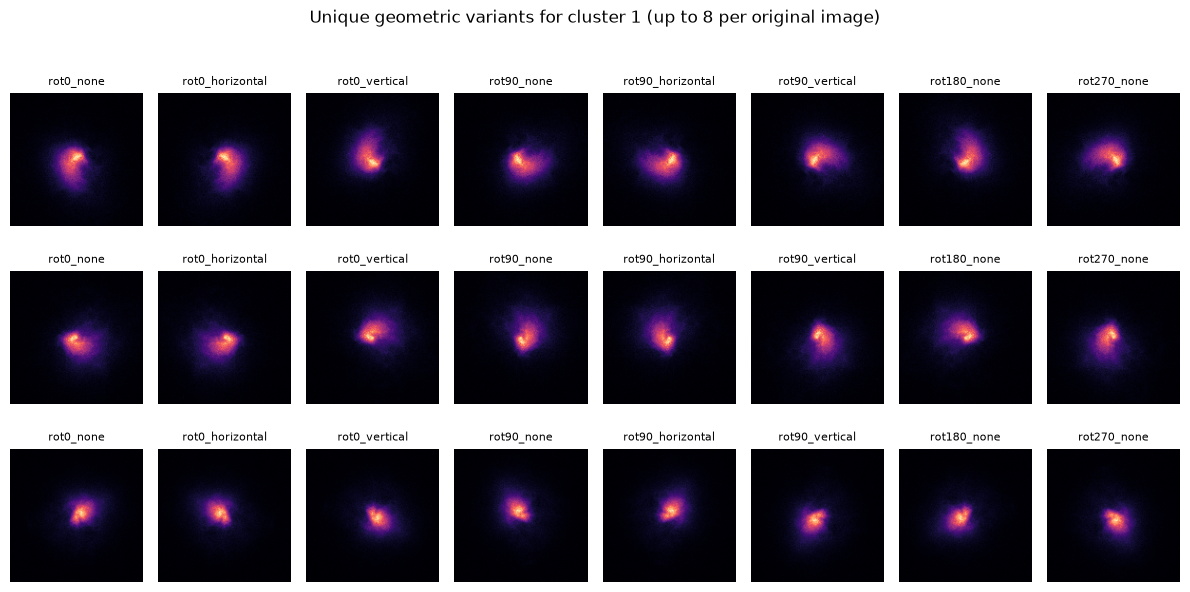

In [8]:
# Display all unique variants for the three original images in one cluster.
fig, axes = plt.subplots(3, 8, figsize=(12, 6))
for row, source_index in enumerate(example_indices):
    variants, names = geometric_variants(images[source_index])
    for column, axis in enumerate(axes[row]):
        axis.axis('off')
        if column < len(variants):
            axis.imshow(variants[column], cmap='magma')
            axis.set_title(names[column], fontsize=8)
    axes[row, 0].set_ylabel(f'LOS {row + 1}', rotation=90, fontsize=10)
plt.suptitle(
    f'Unique geometric variants for cluster {example_cluster} '
    '(up to 8 per original image)',
    y=1.02
)
plt.tight_layout()
plt.show()

### Exampl 2

In [9]:

# Show the redundancy count for one representative cluster.
example_cluster = clusters[5]
example_indices = cluster_indices[example_cluster]
example_counts = []
for source_index in example_indices:
    variants, names = geometric_variants(images[source_index])
    example_counts.append(len(variants))

print(f'Example cluster {example_cluster}: {len(example_indices)} original images')
print(f'Unique variants per image: {example_counts}')
print(f'Unique augmented images in this cluster: {sum(example_counts)}')
assert all(count <= 8 for count in example_counts)
assert sum(example_counts) <= 24

Example cluster 6: 3 original images
Unique variants per image: [8, 8, 8]
Unique augmented images in this cluster: 24


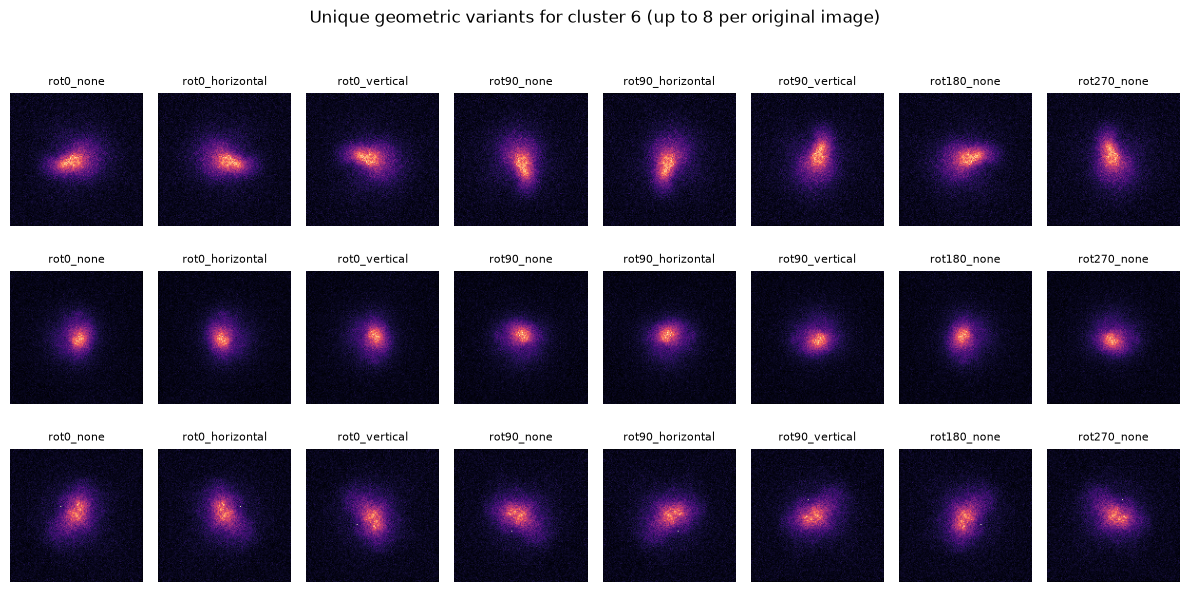

In [10]:
# Display all unique variants for the three original images in one cluster.
fig, axes = plt.subplots(3, 8, figsize=(12, 6))
for row, source_index in enumerate(example_indices):
    variants, names = geometric_variants(images[source_index])
    for column, axis in enumerate(axes[row]):
        axis.axis('off')
        if column < len(variants):
            axis.imshow(variants[column], cmap='magma')
            axis.set_title(names[column], fontsize=8)
    axes[row, 0].set_ylabel(f'LOS {row + 1}', rotation=90, fontsize=10)
plt.suptitle(
    f'Unique geometric variants for cluster {example_cluster} '
    '(up to 8 per original image)',
    y=1.02
)
plt.tight_layout()
plt.show()

### 3. Build the deduplicated augmented dataset

The dataset is augmented cluster by cluster. The source cluster ID is stored for every generated image, which lets cross-validation split on clusters rather than augmented rows. This gives each complete cluster up to 24 images: three original lines of sight times eight unique square-symmetry variants.

In [11]:
augmented_images_list = []
augmented_cluster_ids = []
augmented_masses = []
augmented_transform_names = []

for cluster_id in clusters:
    source_indices = cluster_indices[cluster_id]
    cluster_mass = cluster_masses[cluster_id]
    for source_index in source_indices:
        variants, names = geometric_variants(images[source_index])
        augmented_images_list.extend(variants)
        augmented_cluster_ids.extend([cluster_id] * len(variants))
        augmented_masses.extend([cluster_mass] * len(variants))
        augmented_transform_names.extend(names)

augmented_images = np.stack(augmented_images_list)
augmented_cluster_ids = np.asarray(augmented_cluster_ids)
augmented_masses = np.asarray(augmented_masses)

print(f'Original image rows: {len(images)}')
print(f'Complete-cluster image rows: {sum(len(cluster_indices[cid]) for cid in clusters)}')
print(f'Deduplicated augmented image rows: {len(augmented_images)}')
print(f'Augmented images per complete cluster:')
print(pd.Series(augmented_cluster_ids).value_counts().value_counts().sort_index())

assert set(augmented_cluster_ids) == set(clusters)
assert len(augmented_images) == len(augmented_cluster_ids) == len(augmented_masses)
assert all(
    len(augmented_cluster_ids[augmented_cluster_ids == cluster_id]) <= 24
    for cluster_id in clusters
)

Original image rows: 986
Complete-cluster image rows: 984
Deduplicated augmented image rows: 7872
Augmented images per complete cluster:
count
24    328
Name: count, dtype: int64


### 4. Cluster-level 10-fold CV on the augmented images

The model below uses `build_model(with_rotation=False)`: there is no additional random rotation layer. The explicit rotations and flips are already present in `augmented_images`. Fold assignment is still performed using the original `clusters` array, so no augmented copy of a validation cluster can appear in training.

In [12]:
import time

augmented_indices_by_cluster = {
    cluster_id: np.flatnonzero(augmented_cluster_ids == cluster_id)
    for cluster_id in clusters
}


class MassConvergenceCallback(Callback):
    def __init__(self, validation_data, max_abs_residual=0.3,
                 max_abs_median_residual=0.02, min_slope=0.9):
        super().__init__()
        self.validation_data = validation_data
        self.max_abs_residual = max_abs_residual
        self.max_abs_median_residual = max_abs_median_residual
        self.min_slope = min_slope
        self.converged_epoch = None
        self.criteria_history = []

    def on_epoch_end(self, epoch, logs=None):
        validation_X, validation_Y = self.validation_data
        with tf.device('/CPU:0'):
            predictions = self.model.predict(validation_X, batch_size=batch_size, verbose=0).flatten()
        residuals = validation_Y - predictions
        slope = np.polyfit(validation_Y, predictions, 1)[0]
        criteria = {
            'max_abs_residual': np.max(np.abs(residuals)),
            'median_residual': np.median(residuals),
            'slope': slope,
        }
        self.criteria_history.append(criteria)
        if (
            criteria['max_abs_residual'] < self.max_abs_residual
            and abs(criteria['median_residual']) < self.max_abs_median_residual
            and criteria['slope'] > self.min_slope
        ):
            self.converged_epoch = epoch + 1
            self.model.stop_training = True


def run_augmented_cv():
    fold_results_augmented = []
    fold_histories_augmented = []
    fold_predictions_augmented = []
    total_start = time.perf_counter()
    final_model = None

    print('Starting augmented-data 10-fold cross-validation on CPU:0')
    print(f'Total complete clusters: {len(clusters)}')
    print(f'Total augmented images: {len(augmented_images)}')
    print(f'Configuration: {n_folds} folds, up to {max_epochs} epochs per fold, batch size {batch_size}')
    print('Convergence: max |residual| < 0.3, |median residual| < 0.02, slope > 0.9')
    print('-' * 72)

    for fold, val_clusters in enumerate(mass_balanced_folds, start=1):
        fold_start = time.perf_counter()
        train_clusters = np.asarray([cid for cid in clusters if cid not in val_clusters])
        train_indices = np.concatenate(
            [augmented_indices_by_cluster[cluster_id] for cluster_id in train_clusters]
        )
        val_indices = np.concatenate(
            [augmented_indices_by_cluster[cluster_id] for cluster_id in val_clusters]
        )

        train_X_augmented = augmented_images[train_indices].reshape(
            -1, *augmented_images.shape[1:], 1
        )
        val_X_augmented = augmented_images[val_indices].reshape(
            -1, *augmented_images.shape[1:], 1
        )
        train_Y_augmented = augmented_masses[train_indices]
        val_Y_augmented = augmented_masses[val_indices]

        print(
            f'Fold {fold}/{n_folds} starting | '
            f'train: {len(train_clusters)} clusters, {len(train_indices)} images | '
            f'validation: {len(val_clusters)} clusters, {len(val_indices)} images'
        )

        with tf.device('/CPU:0'):
            model = build_model(
                with_rotation=False,
                input_shape=(*augmented_images.shape[1:], 1)
            )
            convergence = MassConvergenceCallback(
                validation_data=(val_X_augmented, val_Y_augmented)
            )
            history = model.fit(
                train_X_augmented,
                train_Y_augmented,
                validation_data=(val_X_augmented, val_Y_augmented),
                batch_size=batch_size,
                epochs=max_epochs,
                callbacks=[convergence],
                verbose=1
            )
            predictions = model.predict(
                val_X_augmented, batch_size=batch_size, verbose=0
            ).flatten()
        residuals = val_Y_augmented - predictions
        slope = np.polyfit(val_Y_augmented, predictions, 1)[0]
        final_model = model
        fold_histories_augmented.append(history)
        fold_predictions_augmented.append({
            'fold': fold,
            'true': val_Y_augmented.copy(),
            'predicted': predictions.copy(),
            'residuals': residuals.copy(),
        })
        fold_results_augmented.append({
            'fold': fold,
            'r2': r2_score(val_Y_augmented, predictions),
            'mae': mean_absolute_error(val_Y_augmented, predictions),
            'rmse': np.sqrt(mean_squared_error(val_Y_augmented, predictions)),
            'scatter': np.std(residuals),
            'bias': np.mean(residuals),
            'max_abs_residual': np.max(np.abs(residuals)),
            'median_residual': np.median(residuals),
            'slope_true_predicted': slope,
            'converged': convergence.converged_epoch is not None,
            'epochs_trained': len(history.history['loss']),
            'val_loss': history.history['val_loss'][-1],
            'train_images': len(train_indices),
            'val_images': len(val_indices)
        })
        fold_result = fold_results_augmented[-1]
        fold_elapsed = time.perf_counter() - fold_start
        stop_reason = (
            f"converged at epoch {fold_result['epochs_trained']}"
            if fold_result['converged'] else f"fallback at epoch {max_epochs}"
        )
        print(
            f"Fold {fold}/{n_folds} complete in {fold_elapsed / 60:.1f} min | {stop_reason} | "
            f"R2={fold_result['r2']:.4f}, MAE={fold_result['mae']:.4f}, "
            f"RMSE={fold_result['rmse']:.4f}, slope={slope:.4f}"
        )
        print('-' * 72)

    print(f'Augmented 10-fold CV finished in {(time.perf_counter() - total_start) / 60:.1f} min')
    return (
        pd.DataFrame(fold_results_augmented),
        fold_histories_augmented,
        fold_predictions_augmented,
        final_model,
    )

In [13]:
cv_augmented, histories_augmented, fold_predictions_augmented, final_augmented_model = run_augmented_cv()
print('Approach 3: explicit geometric augmentation + cluster-level 10-fold CV')
display(cv_augmented)
print('Output matrix summary:')
display(cv_augmented[
    ['r2', 'mae', 'rmse', 'scatter', 'bias', 'max_abs_residual',
     'median_residual', 'slope_true_predicted', 'epochs_trained', 'val_loss']
].agg(['mean', 'std', 'min', 'max']))

Starting augmented-data 10-fold cross-validation on CPU:0
Total complete clusters: 328
Total augmented images: 7872
Configuration: 10 folds, up to 200 epochs per fold, batch size 64
Convergence: max |residual| < 0.3, |median residual| < 0.02, slope > 0.9
------------------------------------------------------------------------
Fold 1/10 starting | train: 295 clusters, 7080 images | validation: 33 clusters, 792 images
Epoch 1/200


2026-08-28 07:00:19.175289: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-08-28 07:00:19.175319: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-08-28 07:00:19.175326: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1787871619.175338 1316921 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1787871619.175357 1316921 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


111/111 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - loss: 0.1573 - val_loss: 0.0277
Epoch 2/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - loss: 0.0424 - val_loss: 0.0211
Epoch 3/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - loss: 0.0328 - val_loss: 0.0212
Epoch 4/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - loss: 0.0316 - val_loss: 0.0177
Epoch 5/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - loss: 0.0291 - val_loss: 0.0135
Epoch 6/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - loss: 0.0255 - val_loss: 0.0113
Epoch 7/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - loss: 0.0220 - val_loss: 0.0112
Epoch 8/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - loss: 0.0218 - val_loss: 0.0070
Epoch 9/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - loss: 0.0182 - val_loss: 0.0054
Epoch 10/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 0.0122 - val_loss: 0.0047
Epoch 11/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 0.0114 - val_loss: 0.0043
Epoch 12/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 

,fold,r2,mae,rmse,scatter,bias,max_abs_residual,median_residual,slope_true_predicted,converged,epochs_trained,val_loss,train_images,val_images
0,1,0.963539,0.037294,0.046068,0.043892,0.013993,0.130192,0.016490,0.926668,True,26,0.002122,7080,792
1,2,0.655671,0.061421,0.144080,0.139790,0.034898,0.812544,0.013781,0.601530,False,200,0.020759,7080,792
2,3,0.947076,0.037164,0.051446,0.050154,0.011458,0.186398,0.016983,0.945393,True,77,0.002647,7080,792
3,4,0.914542,0.059262,0.076469,0.072739,0.023594,0.243215,0.017737,0.974753,True,14,0.005848,7080,792
4,5,0.927301,0.047393,0.061836,0.060184,0.014199,0.296033,0.016288,0.997712,True,109,0.003824,7080,792
5,6,0.921790,0.054766,0.063947,0.047525,0.042786,0.211865,0.051738,0.904128,False,200,0.004089,7080,792
6,7,0.911200,0.059793,0.070913,0.045574,0.054330,0.163357,0.055334,0.933538,False,200,0.005029,7080,792
7,8,0.829347,0.046216,0.087320,0.087320,-0.000157,0.689640,0.014021,1.127532,False,200,0.007625,7104,768
8,9,0.950486,0.038446,0.049681,0.049570,-0.003319,0.182314,0.002585,0.911472,True,31,0.002468,7080,792
9,10,0.961045,0.034700,0.041239,0.039831,0.010683,0.097092,0.007624,0.902579,True,21,0.001701,7104,768


Output matrix summary:


,r2,mae,rmse,scatter,bias,max_abs_residual,median_residual,slope_true_predicted,epochs_trained,val_loss
mean,0.898200,0.047645,0.069300,0.063658,0.020246,0.301265,0.021258,0.922530,107.800000,0.005611
std,0.093536,0.010511,0.029974,0.030509,0.018594,0.245163,0.017673,0.131219,84.245409,0.005633
min,0.655671,0.034700,0.041239,0.039831,-0.003319,0.097092,0.002585,0.601530,14.000000,0.001701
max,0.963539,0.061421,0.144080,0.139790,0.054330,0.812544,0.055334,1.127532,200.000000,0.020759


# Approach 3 outputs
All models, metrics, fold predictions, histories, plots, and the plotting script are saved under `approach3_outputs`.

In [14]:
from pathlib import Path
import json
output_dir = Path('approach3_outputs')
output_dir.mkdir(exist_ok=True)


In [15]:
final_augmented_model.save(output_dir / 'last_augmented_cv_model.keras')
cv_augmented.to_csv(output_dir / 'cv_augmented.csv', index=False)
np.savez(
    output_dir / 'training_histories_augmented.npz',
    train_loss=np.asarray([h.history['loss'] for h in histories_augmented], dtype=object),
    val_loss=np.asarray([h.history['val_loss'] for h in histories_augmented], dtype=object)
)
np.savez(
    output_dir / 'fold_predictions_augmented.npz',
    true=np.asarray([result['true'] for result in fold_predictions_augmented], dtype=object),
    predicted=np.asarray([result['predicted'] for result in fold_predictions_augmented], dtype=object)
)
(output_dir / 'run_metadata.json').write_text(json.dumps({
    'approach': 3,
    'n_folds': int(n_folds),
    'fold_seed': 42,
    'fold_assignment': 'mass-ranked round-robin at cluster level',
    'augmentation': 'deduplicated D4 transformations',
    'normalization_offset': float(norm_cv),
    'max_epochs': int(max_epochs),
    'convergence_criteria': {
        'max_abs_residual': 0.3,
        'max_abs_median_residual': 0.02,
        'min_slope_true_predicted': 0.9
    }
}, indent=2))
print(f'Saved final augmented model, CV table, predictions, and histories to {output_dir.resolve()}')

Saved final augmented model, CV table, predictions, and histories to /Users/tripathimihir/Documents/a3net_2026/Cluster Mass Hack/approach3_outputs


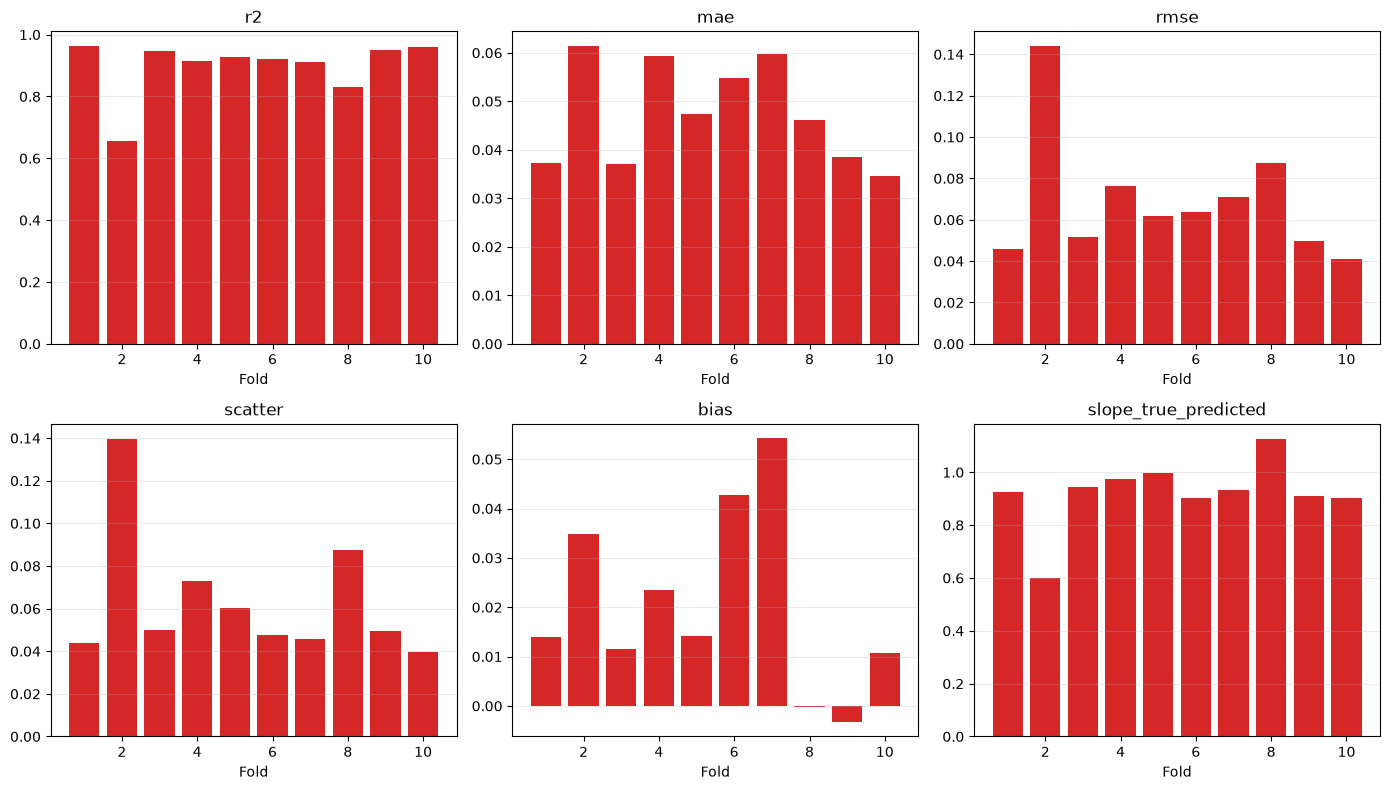

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.

In [16]:
metrics = ['r2', 'mae', 'rmse', 'scatter', 'bias', 'slope_true_predicted']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, metric in zip(axes.flat, metrics):
    axis.bar(cv_augmented['fold'], cv_augmented[metric], color='C3')
    axis.set_title(metric)
    axis.set_xlabel('Fold')
    axis.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(output_dir / 'augmented_cv_metrics_by_fold.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

train_loss = np.asarray([h.history['loss'] for h in histories_augmented])
val_loss = np.asarray([h.history['val_loss'] for h in histories_augmented])
epoch_axis = np.arange(1, train_loss.shape[1] + 1)
fig, axis = plt.subplots(figsize=(10, 6))
for losses, label, color in [(train_loss, 'Training', 'C0'), (val_loss, 'Validation', 'C1')]:
    mean_loss = losses.mean(axis=0)
    std_loss = losses.std(axis=0)
    axis.plot(epoch_axis, mean_loss, color=color, label=f'{label} mean')
    axis.fill_between(epoch_axis, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.18)
axis.set(xlabel='Epoch', ylabel='MSE', title='Augmented CV loss curves')
axis.legend()
fig.tight_layout()
fig.savefig(output_dir / 'augmented_cv_loss_curves.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

# Combine the held-out predictions exactly once: every augmented image is in one fold.
all_true = np.concatenate([result['true'] for result in fold_predictions_augmented]) + norm_cv
all_predicted = np.concatenate([result['predicted'] for result in fold_predictions_augmented]) + norm_cv
all_residuals = all_predicted - all_true
best_fold = int(cv_augmented.loc[cv_augmented['r2'].idxmax(), 'fold'])
best_result = fold_predictions_augmented[best_fold - 1]
best_true = best_result['true'] + norm_cv
best_predicted = best_result['predicted'] + norm_cv
best_residuals = best_predicted - best_true

# Plot residual PDFs and Gaussian fits for the full CV prediction and best-R2 fold.
def gaussian_pdf(values, points):
    mean = np.mean(values)
    standard_deviation = np.std(values, ddof=1)
    density = np.exp(-0.5 * ((points - mean) / standard_deviation) ** 2)
    return density / (standard_deviation * np.sqrt(2 * np.pi)), mean, standard_deviation

fig, axis = plt.subplots(figsize=(10, 6))
for values, label, color in [
    (all_residuals, '10-fold mean', 'C0'),
    (best_residuals, f'Best fit fold ({best_fold})', 'C3'),
]:
    axis.hist(values, bins=30, density=True, alpha=0.28, color=color, label=f'{label} PDF')
    points = np.linspace(values.min(), values.max(), 300)
    density, mean, standard_deviation = gaussian_pdf(values, points)
    axis.plot(points, density, color=color, linewidth=2,
              label=f'{label} Gaussian: mean={mean:.3f}, sigma={standard_deviation:.3f}')
axis.axvline(0, color='black', linewidth=1, linestyle='--')
axis.set(xlabel='log(Mpredicted) - log(Mtrue)', ylabel='Probability density',
        title='Mass-error PDFs with Gaussian fits')
axis.legend()
axis.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(output_dir / 'mass_error_pdfs_gaussian_fit.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

# Plot predicted mass against true mass with the requested one-to-one reference.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
plot_sets = [
    (all_true, all_predicted, '10-fold mean'),
    (best_true, best_predicted, f'Best fit fold ({best_fold})'),
]
axis_limits = [min(all_true.min(), all_predicted.min()), max(all_true.max(), all_predicted.max())]
for axis, (true_values, predicted_values, title) in zip(axes, plot_sets):
    axis.scatter(true_values, predicted_values, s=12, alpha=0.35)
    axis.plot(axis_limits, axis_limits, color='black', linestyle='--', linewidth=1.5, label='1:1')
    axis.set(title=title, xlabel='True log(M500)', xlim=axis_limits, ylim=axis_limits)
    axis.grid(alpha=0.25)
    axis.legend()
axes[0].set_ylabel('Predicted log(M500)')
fig.suptitle('Predicted mass as a function of true mass')
fig.tight_layout()
fig.savefig(output_dir / 'predicted_vs_true_mass.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved augmented CV metrics, loss curves, mass-error PDFs, and predicted-vs-true plots')

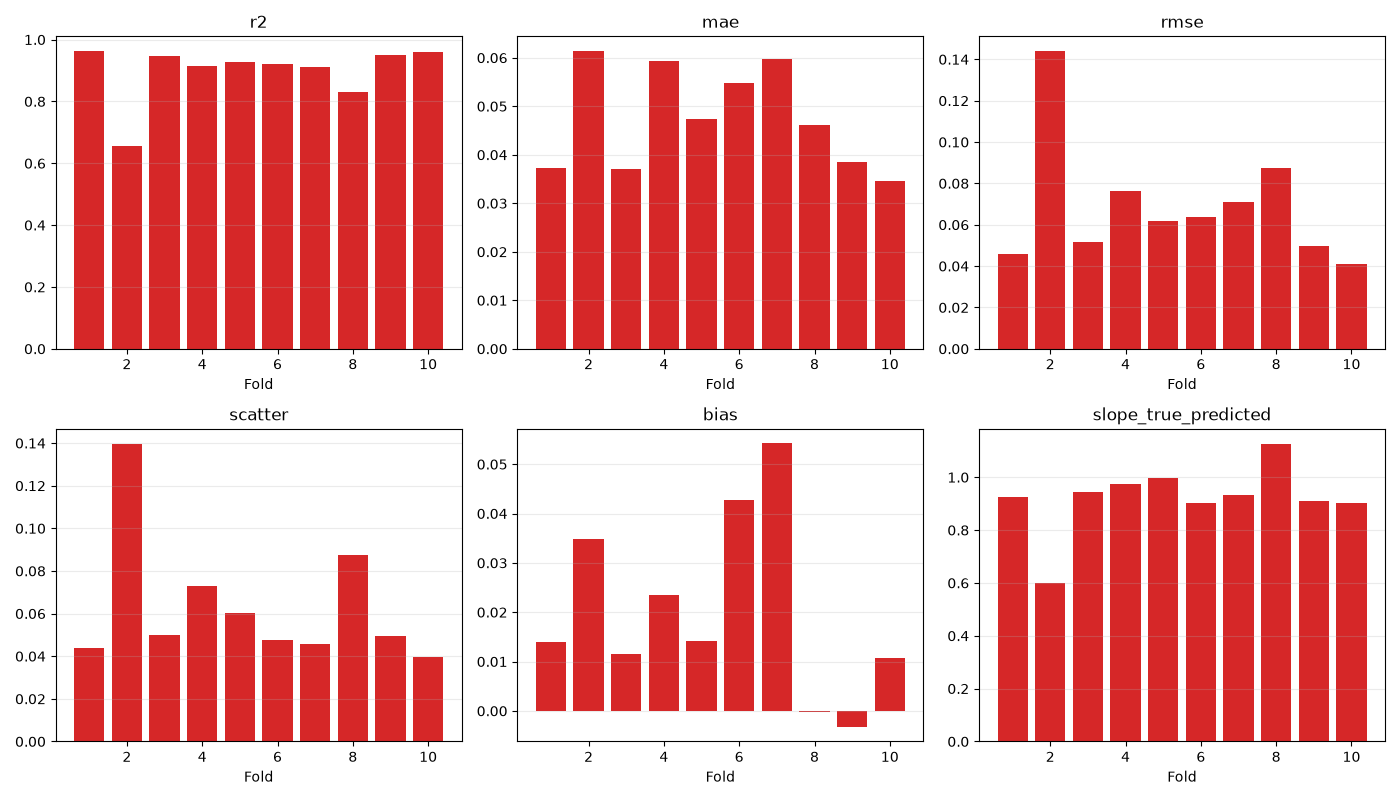

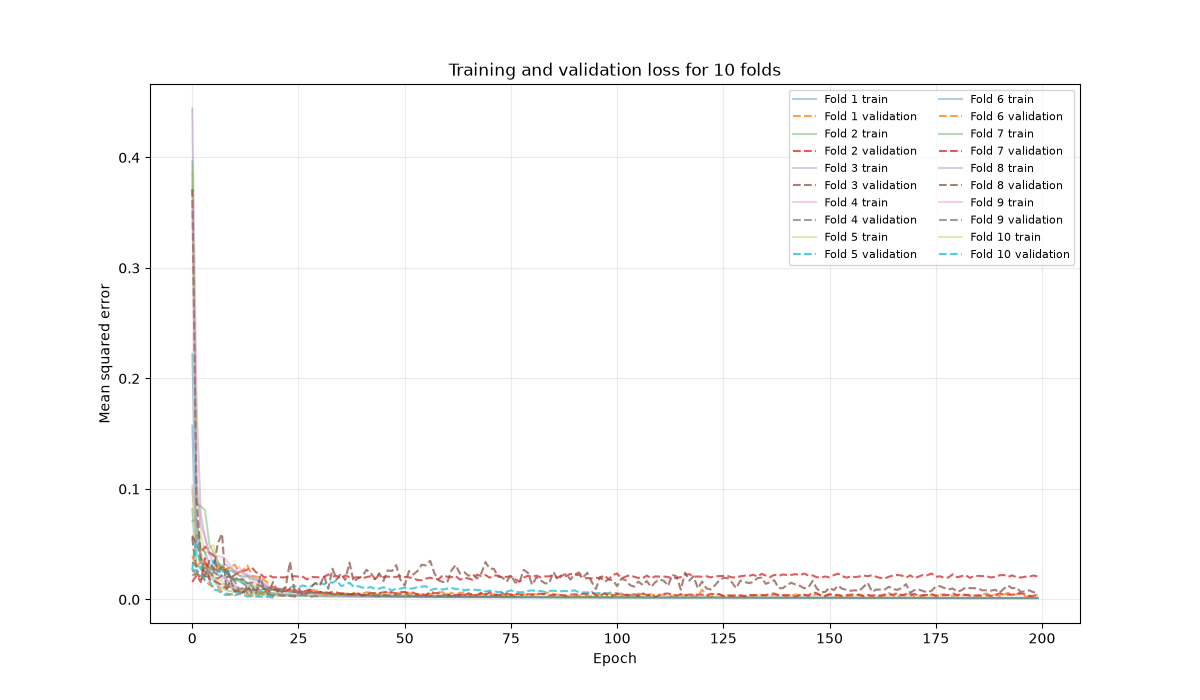

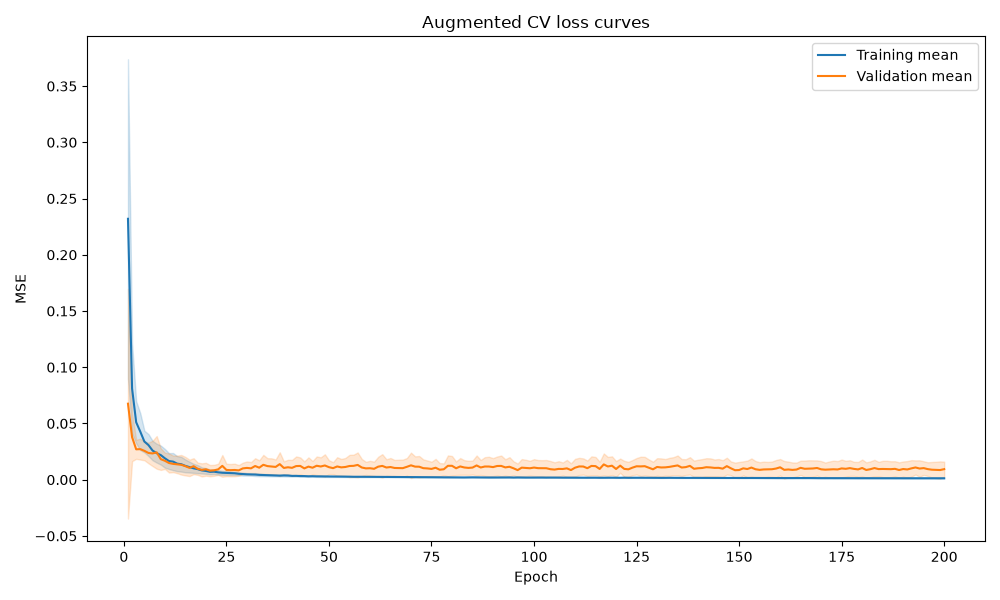

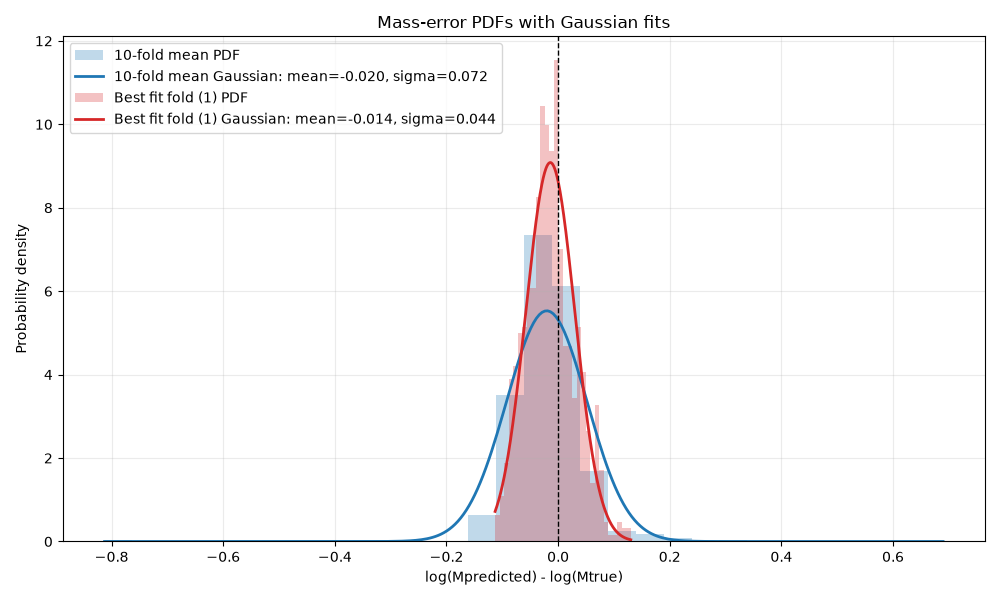

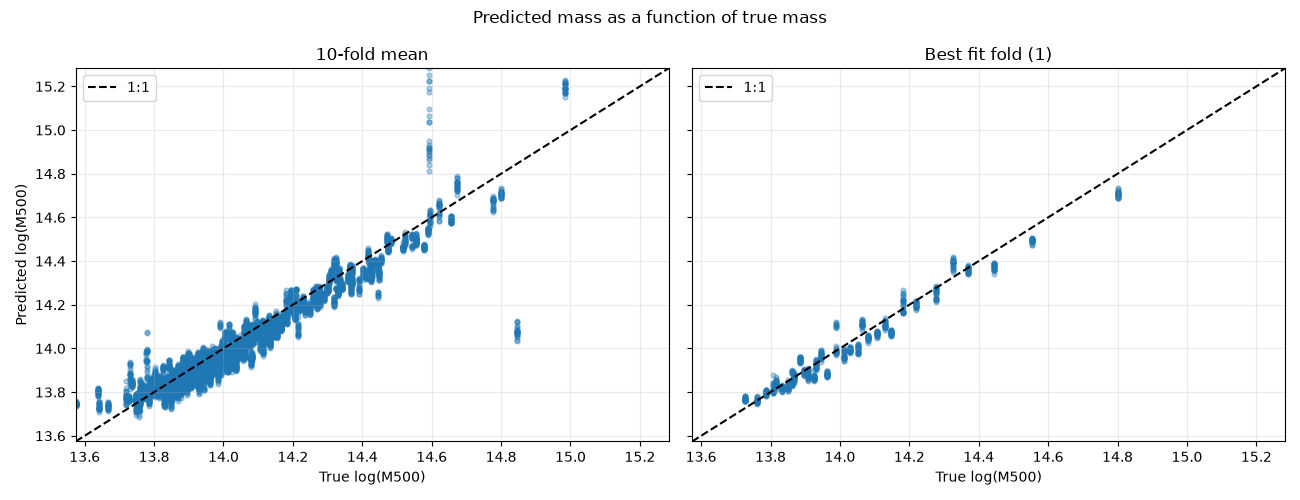

Saved augmented CV metrics, loss curves, mass-error PDFs, and predicted-vs-true plots


In [21]:
metrics = ['r2', 'mae', 'rmse', 'scatter', 'bias', 'slope_true_predicted']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, metric in zip(axes.flat, metrics):
    axis.bar(cv_augmented['fold'], cv_augmented[metric], color='C3')
    axis.set_title(metric)
    axis.set_xlabel('Fold')
    axis.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(output_dir / 'augmented_cv_metrics_by_fold.png', dpi=200, bbox_inches='tight')
plt.show()
#plt.close(fig)

import numpy as np

# 1. Extract the lists of losses
train_loss_list = [h.history['loss'] for h in histories_augmented]
val_loss_list = [h.history['val_loss'] for h in histories_augmented]

# 2. Find the maximum number of epochs any fold trained for
max_epochs = max(len(l) for l in train_loss_list)

# 3. Pad shorter histories with np.nan so they have a uniform shape
train_loss = np.array([l + [np.nan] * (max_epochs - len(l)) for l in train_loss_list])
val_loss = np.array([l + [np.nan] * (max_epochs - len(l)) for l in val_loss_list])

epoch_axis = np.arange(1, max_epochs + 1)




# Plot training and validation loss for every fold.
plt.figure(figsize=(12, 7))
for fold, history in enumerate(histories_augmented, start=1):
    plt.plot(history.history['loss'], alpha=0.35, label=f'Fold {fold} train')
    plt.plot(history.history['val_loss'], alpha=0.75, linestyle='--', label=f'Fold {fold} validation')
plt.xlabel('Epoch')
plt.ylabel('Mean squared error')
plt.title('Training and validation loss for 10 folds')
plt.grid(alpha=0.25)
plt.legend(ncol=2, fontsize=8)
plt.show()






fig, axis = plt.subplots(figsize=(10, 6))

for losses, label, color in [(train_loss, 'Training', 'C0'), (val_loss, 'Validation', 'C1')]:
    # 4. Use nanmean and nanstd to safely ignore the padded NaN values
    mean_loss = np.nanmean(losses, axis=0)
    std_loss = np.nanstd(losses, axis=0)
    
    axis.plot(epoch_axis, mean_loss, color=color, label=f'{label} mean')
    axis.fill_between(epoch_axis, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.18)

axis.set(xlabel='Epoch', ylabel='MSE', title='Augmented CV loss curves')
axis.legend()
fig.tight_layout()
fig.savefig(output_dir / 'augmented_cv_loss_curves.png', dpi=200, bbox_inches='tight')
plt.show()
#plt.close(fig)

# Combine the held-out predictions exactly once: every augmented image is in one fold.
all_true = np.concatenate([result['true'] for result in fold_predictions_augmented]) + norm_cv
all_predicted = np.concatenate([result['predicted'] for result in fold_predictions_augmented]) + norm_cv
all_residuals = all_predicted - all_true
best_fold = int(cv_augmented.loc[cv_augmented['r2'].idxmax(), 'fold'])
best_result = fold_predictions_augmented[best_fold - 1]
best_true = best_result['true'] + norm_cv
best_predicted = best_result['predicted'] + norm_cv
best_residuals = best_predicted - best_true

# Plot residual PDFs and Gaussian fits for the full CV prediction and best-R2 fold.
def gaussian_pdf(values, points):
    mean = np.mean(values)
    standard_deviation = np.std(values, ddof=1)
    density = np.exp(-0.5 * ((points - mean) / standard_deviation) ** 2)
    return density / (standard_deviation * np.sqrt(2 * np.pi)), mean, standard_deviation

fig, axis = plt.subplots(figsize=(10, 6))
for values, label, color in [
    (all_residuals, '10-fold mean', 'C0'),
    (best_residuals, f'Best fit fold ({best_fold})', 'C3'),
]:
    axis.hist(values, bins=30, density=True, alpha=0.28, color=color, label=f'{label} PDF')
    points = np.linspace(values.min(), values.max(), 300)
    density, mean, standard_deviation = gaussian_pdf(values, points)
    axis.plot(points, density, color=color, linewidth=2,
              label=f'{label} Gaussian: mean={mean:.3f}, sigma={standard_deviation:.3f}')
axis.axvline(0, color='black', linewidth=1, linestyle='--')
axis.set(xlabel='log(Mpredicted) - log(Mtrue)', ylabel='Probability density',
        title='Mass-error PDFs with Gaussian fits')
axis.legend()
axis.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(output_dir / 'mass_error_pdfs_gaussian_fit.png', dpi=200, bbox_inches='tight')
plt.show()
#plt.close(fig)

# Plot predicted mass against true mass with the requested one-to-one reference.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
plot_sets = [
    (all_true, all_predicted, '10-fold mean'),
    (best_true, best_predicted, f'Best fit fold ({best_fold})'),
]
axis_limits = [min(all_true.min(), all_predicted.min()), max(all_true.max(), all_predicted.max())]
for axis, (true_values, predicted_values, title) in zip(axes, plot_sets):
    axis.scatter(true_values, predicted_values, s=12, alpha=0.35)
    axis.plot(axis_limits, axis_limits, color='black', linestyle='--', linewidth=1.5, label='1:1')
    axis.set(title=title, xlabel='True log(M500)', xlim=axis_limits, ylim=axis_limits)
    axis.grid(alpha=0.25)
    axis.legend()
axes[0].set_ylabel('Predicted log(M500)')
fig.suptitle('Predicted mass as a function of true mass')
fig.tight_layout()
fig.savefig(output_dir / 'predicted_vs_true_mass.png', dpi=200, bbox_inches='tight')
plt.show()
#plt.close(fig)
print('Saved augmented CV metrics, loss curves, mass-error PDFs, and predicted-vs-true plots')

In [ ]:
plot_script = r'''from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path(__file__).resolve().parent
results = pd.read_csv(OUTPUT_DIR / 'cv_augmented.csv')
predictions = np.load(OUTPUT_DIR / 'fold_predictions_augmented.npz', allow_pickle=True)
metadata = __import__('json').loads((OUTPUT_DIR / 'run_metadata.json').read_text())
norm_cv = metadata.get('normalization_offset', 0.0)
true_by_fold = predictions['true']
predicted_by_fold = predictions['predicted']
all_true = np.concatenate(true_by_fold) + norm_cv
all_predicted = np.concatenate(predicted_by_fold) + norm_cv
best_fold = int(results.loc[results['r2'].idxmax(), 'fold'])
best_true = true_by_fold[best_fold - 1] + norm_cv
best_predicted = predicted_by_fold[best_fold - 1] + norm_cv

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, metric in zip(axes.flat, ['r2', 'mae', 'rmse', 'scatter', 'bias', 'slope_true_predicted']):
    axis.bar(results['fold'], results[metric], color='C3')
    axis.set(title=metric, xlabel='Fold')
    axis.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'augmented_cv_metrics_by_fold.png', dpi=200, bbox_inches='tight')
plt.close(fig)

fig, axis = plt.subplots(figsize=(10, 6))
for values, label, color in [(all_predicted - all_true, '10-fold mean', 'C0'), (best_predicted - best_true, f'Best fit fold ({best_fold})', 'C3')]:
    axis.hist(values, bins=30, density=True, alpha=0.28, color=color, label=f'{label} PDF')
    points = np.linspace(values.min(), values.max(), 300)
    mean, sigma = np.mean(values), np.std(values, ddof=1)
    axis.plot(points, np.exp(-0.5 * ((points - mean) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi)), color=color, label=f'{label}: mean={mean:.3f}, sigma={sigma:.3f}')
axis.axvline(0, color='black', linestyle='--')
axis.set(xlabel='log(Mpredicted) - log(Mtrue)', ylabel='Probability density', title='Mass-error PDFs with Gaussian fits')
axis.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'mass_error_pdfs_gaussian_fit.png', dpi=200, bbox_inches='tight')
plt.close(fig)

limits = [min(all_true.min(), all_predicted.min()), max(all_true.max(), all_predicted.max())]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for axis, true_values, predicted_values, title in zip(axes, [all_true, best_true], [all_predicted, best_predicted], ['10-fold mean', f'Best fit fold ({best_fold})']):
    axis.scatter(true_values, predicted_values, s=12, alpha=0.35)
    axis.plot(limits, limits, 'k--', linewidth=1.5, label='1:1')
    axis.set(title=title, xlabel='True log(M500)', xlim=limits, ylim=limits)
    axis.grid(alpha=0.25)
    axis.legend()
axes[0].set_ylabel('Predicted log(M500)')
fig.suptitle('Predicted mass as a function of true mass')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'predicted_vs_true_mass.png', dpi=200, bbox_inches='tight')
plt.close(fig)
print(f'Plots regenerated in {OUTPUT_DIR}')
'''
(output_dir / 'plot_outputs.py').write_text(plot_script)
print(f'Saved plotting script to {(output_dir / "plot_outputs.py").resolve()}')

Saved plotting script to /Users/tripathimihir/Documents/a3net_2026/Cluster Mass Hack/approach3_outputs/plot_outputs.py
